# ER Diagram for the AISYNPHYS Dataset

<!-- <img src="er_diagram.png" alt="ER diagram" width="400" height="200">
<p align="center"><img src="image.png" alt="Centered image"></p> -->

The ER diagram does not include everything, it includes the most common subset used. Full description at https://aisynphys.readthedocs.io/en/current-release/api_schema.html#api-schema

![ER Diagram](er_diagram.png "ER diagram")

# Initialization, setting up connection

To get this working, I have:
* Downloaded aisynphys source code
* Downloaded neuroanalysis source code
* Set up environment in anaconda, with python 3.9:

```powershell
# clone repo aisynphys
# change to python 3.9 in yaml
mamba create -n aisynphys39 python=3.9
conda activate aisynphys39
mamba install numpy scipy pandas matplotlib sqlalchemy pyqt pyqtgraph numba h5py -c conda-forge
pip install lmfit
cd C:\Users\myuser\src\aisynphys
python setup.py develop
# cd to user
git clone https://github.com/alleninstitute/neuroanalysis
cd C:\Users\myuser\neuroanalysis
python setup.py develop
# Then was a problem with missing pyyaml, so downloaded that
mamba install -c conda-forge pyyaml
```

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3
from IPython.display import display, Markdown
from pathlib import Path
import os
import math

# AISYNPHYS stuff
import pyqtgraph
import neuroanalysis
import neuroanalysis.util
import aisynphys
import aisynphys.database

# Prints
print(aisynphys.__file__)
print(pyqtgraph.__file__)
print(neuroanalysis.__file__)

# Load matplotlib style
plt.style.use('plos.mplstyle')

# File path handling
# SCRIPT_DIR = Path(__file__).resolve().parent  # .py
SCRIPT_DIR = Path.cwd()  # .ipynb
FIGURES_DIR = SCRIPT_DIR / "figures_analysis"
print(f"Figure path: {FIGURES_DIR}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------

# Load DB
from aisynphys.database import SynphysDatabase # https://aisynphys.readthedocs.io/en/current-release/database_access.html#database-access



CACHE_PATH = Path("data/aisynphys/cache").resolve()  # Define cache directory
CACHE_PATH.mkdir(parents=True, exist_ok=True)  # Create a cache directory if it does not exist
aisynphys.config.cache_path = CACHE_PATH  # Tell AISynPhys to use this cache
DATA_ROOT = Path("data/aisynphys/cache")  # Make cache
SynphysDatabase.list_versions()  # List all available versions


# DB_VERSION = 'synphys_r2.1_medium.sqlite'  # Medium database
DB_VERSION = 'synphys_r2.1_full.sqlite'  # Full database

db = SynphysDatabase.load_version(DB_VERSION)  # Load DB
print(f"Loaded version: {DB_VERSION}")

# ------------------------------------------------------------
# Set up connection


# DB_PATH = Path('data/aisynphys/cache/database/synphys_r2.1_medium.sqlite').resolve()  # Medium database
DB_PATH = Path('data/aisynphys/cache/database/synphys_r2.1_full.sqlite').resolve()  # Full database
assert DB_PATH.exists(), f"Database file not found: {DB_PATH}"  # Ensure existence


con = sqlite3.connect(DB_PATH)  # Create SQLite connection to SQLite database
con.create_function("SQRT", 1, math.sqrt)   # now SQLite understands SQRT()
cur = con.cursor()  # database cursor
print(f"Connection set up to {DB_PATH}")

C:\Users\snrambo\aisynphys\aisynphys\__init__.py
c:\Users\snrambo\AppData\Local\miniconda3\envs\aisynphys39\lib\site-packages\pyqtgraph\__init__.py
C:\Users\snrambo\neuroanalysis\neuroanalysis\__init__.py
Figure path: c:\Users\snrambo\Projects\NEVR3901\HeterogenousRNN\HeterogeneousRNNs\data_analysis\figures_analysis
Loaded version: synphys_r2.1_full.sqlite
Connection set up to C:\Users\snrambo\Projects\NEVR3901\HeterogenousRNN\HeterogeneousRNNs\data_analysis\data\aisynphys\cache\database\synphys_r2.1_full.sqlite


In [ ]:
# If need to close

cur.close()
con.close()

# Overview of database

In [ ]:
query = """
SELECT
    *
FROM cortical_cell_location
;
"""

df = pd.read_sql_query(query, con)

df


,id,cell_id,cortical_site_id,cortical_layer,distance_to_pia,distance_to_wm,fractional_depth,layer_depth,layer_thickness,fractional_layer_depth,position,meta
0,1,23746,None,2/3,0.000138,0.000762,0.153047,0.000021,0.000232,0.091119,"[0.008239340400000001, 0.0021437849999999996]","{""lims_layer"": ""2/3""}"
1,2,23747,None,2/3,0.000177,0.000725,0.196311,0.000060,0.000234,0.256232,"[0.0081982662, 0.0021499101]","{""lims_layer"": ""2/3""}"
2,3,23748,None,2/3,0.000160,0.000748,0.176041,0.000043,0.000239,0.180707,"[0.0081568317, 0.0020565924]","{""lims_layer"": ""2/3""}"
3,4,23749,None,2/3,0.000131,0.000777,0.144023,NaN,NaN,NaN,"[0.0081863763, 0.0020475849]","{""lims_layer"": ""2/3""}"
4,5,4774,None,2/3,0.000177,0.000619,0.221883,0.000061,0.000123,0.496334,"[0.0034513137, 0.0010567598999999999]","{""lims_layer"": ""2/3""}"
...,...,...,...,...,...,...,...,...,...,...,...,...
12446,12447,9761,None,3,0.001238,0.001909,0.393326,0.000751,0.000837,0.897581,"[0.0044035866, 0.0026215428]","{""lims_layer"": ""3""}"
12447,12448,9762,None,3,0.001274,0.001874,0.404664,0.000786,0.000835,0.942167,"[0.0043945791, 0.002659014]","{""lims_layer"": ""3""}"
12448,12449,9763,None,4,0.001385,0.001758,0.440690,0.000061,0.000242,0.249989,"[0.0042727977, 0.0027126986999999997]","{""lims_layer"": ""4""}"
12449,12450,9764,None,3,0.001317,0.001821,0.419584,0.000838,0.000847,0.989631,"[0.0042609078, 0.0026258664]","{""lims_layer"": ""3""}"


In [19]:
query = """
SELECT
    cre_type,
    COUNT(*) AS n_cells
FROM cell
GROUP BY cre_type
ORDER BY n_cells DESC;
"""

df = pd.read_sql_query(query, con)

df

,cre_type,n_cells
0,unknown,15303
1,sst,2569
2,pvalb,2378
3,vip,1406
4,tlx3,1206
5,sim1,668
6,ntsr1,458
7,nr5a1,351
8,rorb,191
9,fam84b,76


In [5]:
table_list = cur.execute(
    "SELECT name FROM sqlite_master WHERE type='table'"
).fetchall()

for i, name in enumerate(table_list):
    print(i, name[0])


# Because they are stored in the form of ('pair',), accessing them by (str(list[i])[2:-3]) displays from the third index which is the first letter (excluding "('" ), and excluding the last "',)"
print(f"{str(table_list[9])[2:-3]}\n{str(table_list[20])[2:-3]}")

0 metadata
1 pipeline
2 slice
3 experiment
4 electrode
5 sync_rec
6 cortical_site
7 cell
8 recording
9 pair
10 intrinsic
11 morphology
12 test_pulse
13 stim_pulse
14 baseline
15 cortical_cell_location
16 patch_seq
17 patch_clamp_recording
18 stim_spike
19 pulse_response
20 synapse
21 poly_synapse
22 dynamics
23 synapse_prediction
24 gap_junction
25 synapse_model
26 multi_patch_probe
27 avg_response_fit
28 pulse_response_fit
29 pulse_response_strength
30 resting_state_fit
31 conductance
pair
synapse


In [ ]:
query = """
            SELECT fi_slope FROM intrinsic
            WHERE fi_slope IS NOT NULL
            ORDER BY fi_slope DESC
            ;
        """

df = pd.read_sql_query(query, con)

df


,fi_slope
0,3.894356e-11
1,3.199994e-11
2,5.871778e-12
3,5.325688e-12
4,5.300000e-12
...,...
4614,-1.073825e-12
4615,-1.267327e-12
4616,-1.350000e-12
4617,-1.199993e-11


In [ ]:
slope_vals = cur.execute("""SELECT MAX(fi_slope), MIN(fi_slope), AVG(fi_slope) FROM intrinsic""").fetchall()

print(slope_vals[0])

(3.8943561546762944e-11, -3.20000305176071e-11, 3.5902876328371054e-13)


In [ ]:
# Here I just show that there is only one PSP amplitude associated with a synapse


query = """ 
SELECT
    pair_id,
    COUNT(*) AS n_synapses
FROM synapse
GROUP BY pair_id
HAVING COUNT(*) > 1
ORDER BY n_synapses DESC;
"""

df = pd.read_sql_query(query, con)

df

,pair_id,n_synapses


# Query

Querying connections with associated pre- and postsynaptic cell info

In [6]:
query = """ 

SELECT
    p.experiment_id,
    p.pre_cell_id,
    p.post_cell_id,
    p.has_synapse,
    pre.cell_class  AS pre_cell_class,
    post.cell_class AS post_cell_class,
    i_pre.fi_slope  AS fi_slope_pre,   -- presynaptic fI slope
    i_post.fi_slope AS fi_slope_post,  -- postsynaptic fI slope
    --pre.cre_type AS pre_cre_type,
    --post.cre_type AS post_cre_type,
    --pre_cell_loc.cortical_layer AS pre_cortical_layer,
    --post_cell_loc.cortical_layer AS post_cortical_layer,
    CASE
        WHEN p.has_synapse = 1 THEN syn.psp_amplitude
        ELSE NULL                     -- to keep entries where there was not a synapse
    END AS psp_amplitude
FROM pair AS p
JOIN cell       AS pre   ON p.pre_cell_id  = pre.id  
JOIN cell       AS post  ON p.post_cell_id = post.id
JOIN cortical_cell_location AS pre_cell_loc ON p.pre_cell_id = pre_cell_loc.cell_id
JOIN cortical_cell_location AS post_cell_loc ON p.post_cell_id = post_cell_loc.cell_id
JOIN intrinsic  AS i_pre ON p.pre_cell_id  = i_pre.cell_id
JOIN intrinsic  AS i_post ON p.post_cell_id = i_post.cell_id
LEFT JOIN synapse AS syn   ON syn.pair_id = p.id          -- can be NULL
JOIN experiment AS e     ON e.id = p.experiment_id
JOIN slice      AS s     ON e.slice_id = s.id
WHERE
    s.species = 'mouse'
    AND i_pre.fi_slope IS NOT NULL
    AND i_post.fi_slope IS NOT NULL
    AND p.has_synapse IS NOT NULL   -- only defined synapses
    AND (p.has_synapse = 0 OR (p.has_synapse = 1 AND syn.psp_amplitude IS NOT NULL))  -- no included synapses where there is nan value in psp amplitude
    ;


        """

main = pd.read_sql_query(query, con)
df = main.copy()

df.to_csv('preprocessed_data.csv', index=False)

df


,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,psp_amplitude
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,NaN
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,NaN
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,NaN
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,NaN
4,600,4138,4142,0,in,in,1.105000e-12,8.820777e-13,NaN
...,...,...,...,...,...,...,...,...,...
7419,5004,24565,24564,1,in,in,4.807973e-13,1.739197e-13,-0.001123
7420,5004,24567,24564,1,in,in,7.191986e-13,1.739197e-13,-0.000221
7421,5105,24778,24781,1,mixed,ex,8.018796e-13,9.525691e-14,-0.000198
7422,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,-0.000314


In [8]:
query = """ 

SELECT
    p.experiment_id,
    p.pre_cell_id,
    p.post_cell_id,
    p.has_synapse,
    pre.cell_class  AS pre_cell_class,
    post.cell_class AS post_cell_class,
    i_pre.fi_slope  AS fi_slope_pre,   -- presynaptic fI slope
    i_post.fi_slope AS fi_slope_post,  -- postsynaptic fI slope
    CASE
        WHEN p.has_synapse = 1 THEN syn.psp_amplitude
        ELSE NULL                     -- to keep entries where there was not a synapse
    END AS psp_amplitude
FROM pair AS p
JOIN cell       AS pre   ON p.pre_cell_id  = pre.id  
JOIN cell       AS post  ON p.post_cell_id = post.id
JOIN intrinsic  AS i_pre ON p.pre_cell_id  = i_pre.cell_id
JOIN intrinsic  AS i_post ON p.post_cell_id = i_post.cell_id
LEFT JOIN synapse AS syn   ON syn.pair_id = p.id          -- can be NULL
JOIN experiment AS e     ON e.id = p.experiment_id
JOIN slice      AS s     ON e.slice_id = s.id
WHERE
    s.species = 'mouse'
    AND i_pre.fi_slope IS NOT NULL
    AND i_post.fi_slope IS NOT NULL
    AND p.has_synapse IS NOT NULL   -- only defined synapses
    AND (p.has_synapse = 0 OR (p.has_synapse = 1 AND syn.psp_amplitude IS NOT NULL))  -- no included synapses where there is nan value in psp amplitude
    ;


        """

main = pd.read_sql_query(query, con)
df = main.copy()

df.to_csv('preprocessed_data.csv', index=False)

df


,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,psp_amplitude
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,NaN
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,NaN
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,NaN
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,NaN
4,600,4138,4142,0,in,in,1.105000e-12,8.820777e-13,NaN
...,...,...,...,...,...,...,...,...,...
8716,5004,24565,24564,1,in,in,4.807973e-13,1.739197e-13,-0.001123
8717,5004,24567,24564,1,in,in,7.191986e-13,1.739197e-13,-0.000221
8718,5105,24778,24781,1,mixed,ex,8.018796e-13,9.525691e-14,-0.000198
8719,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,-0.000314


In [19]:
import pandas as pd

df = pd.read_csv("preprocessed_data.csv")
df


df_temp = df[df["psp_amplitude"].notna()]

df_temp


,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,psp_amplitude
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,-0.000204
6,600,4140,4133,1,ex,in,1.131452e-13,8.230065e-13,0.000445
27,610,4199,4201,1,ex,ex,-1.923071e-15,7.692308e-14,0.000030
35,614,4225,4227,1,in,ex,6.599999e-13,2.000000e-13,-0.000168
117,699,4698,4700,1,ex,in,1.158730e-13,-1.269841e-14,0.000038
...,...,...,...,...,...,...,...,...,...
8933,5004,24565,24564,1,in,in,4.807973e-13,1.739197e-13,-0.001123
8936,5004,24567,24564,1,in,in,7.191986e-13,1.739197e-13,-0.000221
8954,5105,24778,24781,1,mixed,ex,8.018796e-13,9.525691e-14,-0.000198
8957,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,-0.000314


Negative f-I slope

In [15]:
df = pd.read_csv("preprocessed_data.csv")
df

df_temp = df[(df["fi_slope_pre"]<0) | (df["fi_slope_post"]<0)]

df_temp

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,psp_amplitude
24,610,4197,4199,0,in,ex,-9.612794e-14,-1.923071e-15,NaN
25,610,4197,4201,0,in,ex,-9.612794e-14,7.692308e-14,NaN
26,610,4199,4197,0,ex,in,-1.923071e-15,-9.612794e-14,NaN
27,610,4199,4201,1,ex,ex,-1.923071e-15,7.692308e-14,0.00003
28,610,4201,4197,0,ex,in,7.692308e-14,-9.612794e-14,NaN
...,...,...,...,...,...,...,...,...,...
8940,5006,24572,24569,0,ex,in,-9.353033e-31,8.000000e-13,NaN
8941,5006,24572,24574,1,ex,in,-9.353033e-31,6.850017e-13,NaN
8943,5006,24574,24572,0,in,ex,6.850017e-13,-9.353033e-31,NaN
8952,5104,24775,24776,0,in,NaN,-1.567897e-13,5.536332e-15,NaN


# Analysis of PSP Amplitude vs. F-I slope

We want to investigate distribution of weights for which the postsynaptic neurons belong to each f-I category. We let experiments count as 'seeds', and take mean and standard deviation of of PSPamplitude across experiments per f-I slope category of postsynaptic cell, where presynaptic cell can be either.

Plot just PSP Amplitude vs. f-I slope, no categorization   

In [10]:
df = pd.read_csv("preprocessed_data.csv")

df_temp = df[(df["has_synapse"]==1) & (df["psp_amplitude"].isna())]

df_temp

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,psp_amplitude


In [9]:
df = pd.read_csv("preprocessed_data.csv")

# exp = df["experiment_id"].unique()

# df = df.dropna(subset=["psp_amplitude"])

print(f"--- Before dividing into FI slope categories ---:")

print(f"Number of ...")
print(f" unique experiments: {len(df['experiment_id'].unique())}")
print(f" cells involved: {len(pd.unique(df[['pre_cell_id', 'post_cell_id']].values.ravel()))}")
print(f" connections recorded: {len(df['has_synapse'])}")
print(f" synapses that occurred: {len(df[df['has_synapse']==1])}")
print(f" synapses where there was a recorded PSP Amplitude: {len(df['psp_amplitude'].dropna())}")

# df_proc = pd.read_csv("preprocessed_data_categorized_smallhigh.csv")

# print(f"--- After dividing into FI slope categories ---:")
# print(f"Number of ...")
# print(f" unique experiments: {len(df_proc['experiment_id'].unique())}")
# print(f" cells involved: {len(pd.unique(df_proc[['pre_cell_id', 'post_cell_id']].values.ravel()))}")
# print(f" connections recorded: {len(df_proc['has_synapse'])}")
# print(f" synapses that occurred: {len(df_proc[df_proc['has_synapse']==1])}")
# print(f" synapses where there was a recorded PSP Amplitude: {len(df_proc['psp_amplitude'].dropna())}")
# print(f" records of postsynaptic cells instances of small FI slope: {len(df_proc[df_proc['category']=='small'])}")
# print(f" records of postsynaptic cells instances of high FI slope: {len(df_proc[df_proc['category']=='high'])}")


--- Before dividing into FI slope categories ---:
Number of ...
 unique experiments: 965
 cells involved: 3189
 connections recorded: 8721
 synapses that occurred: 621
 synapses where there was a recorded PSP Amplitude: 621


In [17]:
#Various prints


import pandas as pd
df = pd.read_csv("preprocessed_data.csv")
dfA = df.copy()

print(f"There was {dfA['experiment_id'].nunique()} unique experiments")  # unique experiments
pre_cells  = dfA["pre_cell_id"].unique()
post_cells = dfA["post_cell_id"].unique()
all_cells = np.unique(np.concatenate((pre_cells, post_cells)))
print(f"Possible connections: {len(dfA['has_synapse'])}")
syn = dfA[dfA['has_synapse']==1]
print(f"Formed synapse: {len(syn['has_synapse'])}")
print(f"There was {dfA['pre_cell_id'].nunique()} pre cells")
print(f"There was {dfA['post_cell_id'].nunique()} post cells")
print(f"There was {len(all_cells)} cells involved")



df = pd.read_csv("preprocessed_data.csv")
df_psp = df[df["psp_amplitude"].notna()].copy()
print(f"Synapses without NaN: {len(df_psp['has_synapse'])}")

synapse_counts = (
    df_psp
    .groupby("post_cell_id")
    .size()
    .sort_values(ascending=False)
)
print("Average synapses per postsynaptic neuron:",
      synapse_counts.mean())
synapse_counts.head(10)


There was 966 unique experiments
Possible connections: 8962
Formed synapse: 862
There was 3189 pre cells
There was 3189 post cells
There was 3191 cells involved
Synapses without NaN: 621
Average synapses per postsynaptic neuron: 1.2011605415860735


post_cell_id
18060    5
18061    5
10622    4
18065    4
16650    3
15868    3
19143    3
16314    3
14898    3
15836    3
dtype: int64

C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\323795527.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


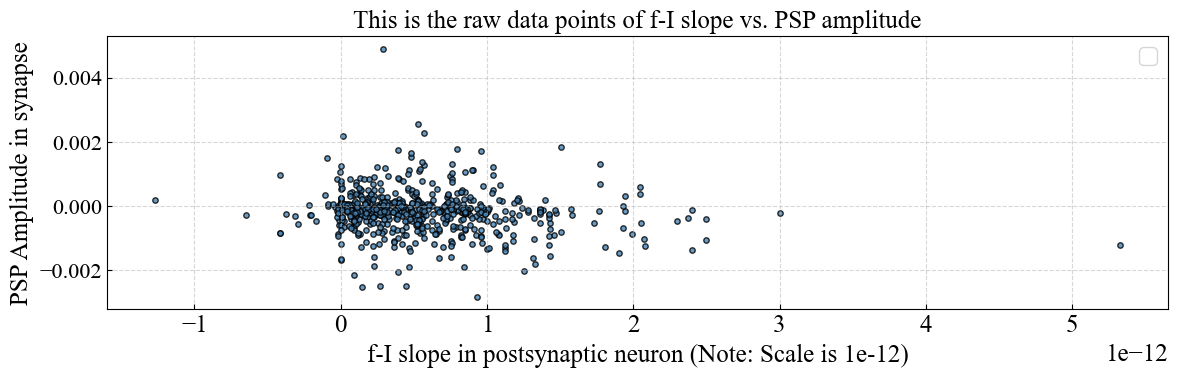

In [102]:
import pandas as pd

df = pd.read_csv("preprocessed_data.csv")

dfA = df.copy()

dfA_nonan = dfA.dropna(subset=["psp_amplitude"])  # exclude those that contain NaN values in PSP amplitude

import numpy as np

# View cutoffs


df_synapses = dfA_nonan[dfA_nonan["has_synapse"]==1]

df_synapses

# print(f"Number of unique synapses: {len(df_synapses['synapse_id'].unique())}")

df_xy = df_synapses[["fi_slope_post", "psp_amplitude"]]

plt.figure(figsize=(12, 4))
plt.scatter(df_xy["fi_slope_post"], df_xy["psp_amplitude"], color="steelblue", s=15, alpha=0.8, edgecolor="k")
plt.title("This is the raw data points of f-I slope vs. PSP amplitude")
plt.xlabel("f-I slope in postsynaptic neuron (Note: Scale is 1e-12)")
plt.ylabel("PSP Amplitude in synapse")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



FI slopes: [1.1314518997244929e-13, 8.230065275570382e-13, 7.692308149393981e-14, 2e-13, -1.2698412698412691e-14, 5.062499930755573e-13, 6.240000309448212e-14, 4.3474285483161694e-13, -6.942505546770364e-15, 9.062499891607815e-13, -2.1930501930501898e-13, -3.999998735700493e-14, 2.428571353315485e-13, 4.45714243591726e-13, -1.3559321157208228e-14, -1.3559321157208228e-14, 2.428571353315485e-13, 4.45714243591726e-13, -1.9685041005704823e-14, 1.1851430090680786e-12, 1.399999889373778e-13, 1.8999994970251957e-12, 8.688916827967505e-13, 9.285713940055957e-13, -8.648648648648622e-14, 6.728571482132788e-13, -8.648648648648622e-14, 9.285713940055957e-13, 2.702701588109368e-14, 1.0656370656370646e-13, 5.649999656677224e-13, 5.649999656677224e-13, -2.0758367494562238e-13, 0.0, 1.0285714156539152e-13, 4.552422805491578e-13, 6.509530714398713e-13, 7.862572646808148e-13, 6.371428369119826e-13, 2.791116663303136e-13, 4.399999839419386e-13, 4.814285317972421e-13, 7.640001491699337e-13, 2.66666666666

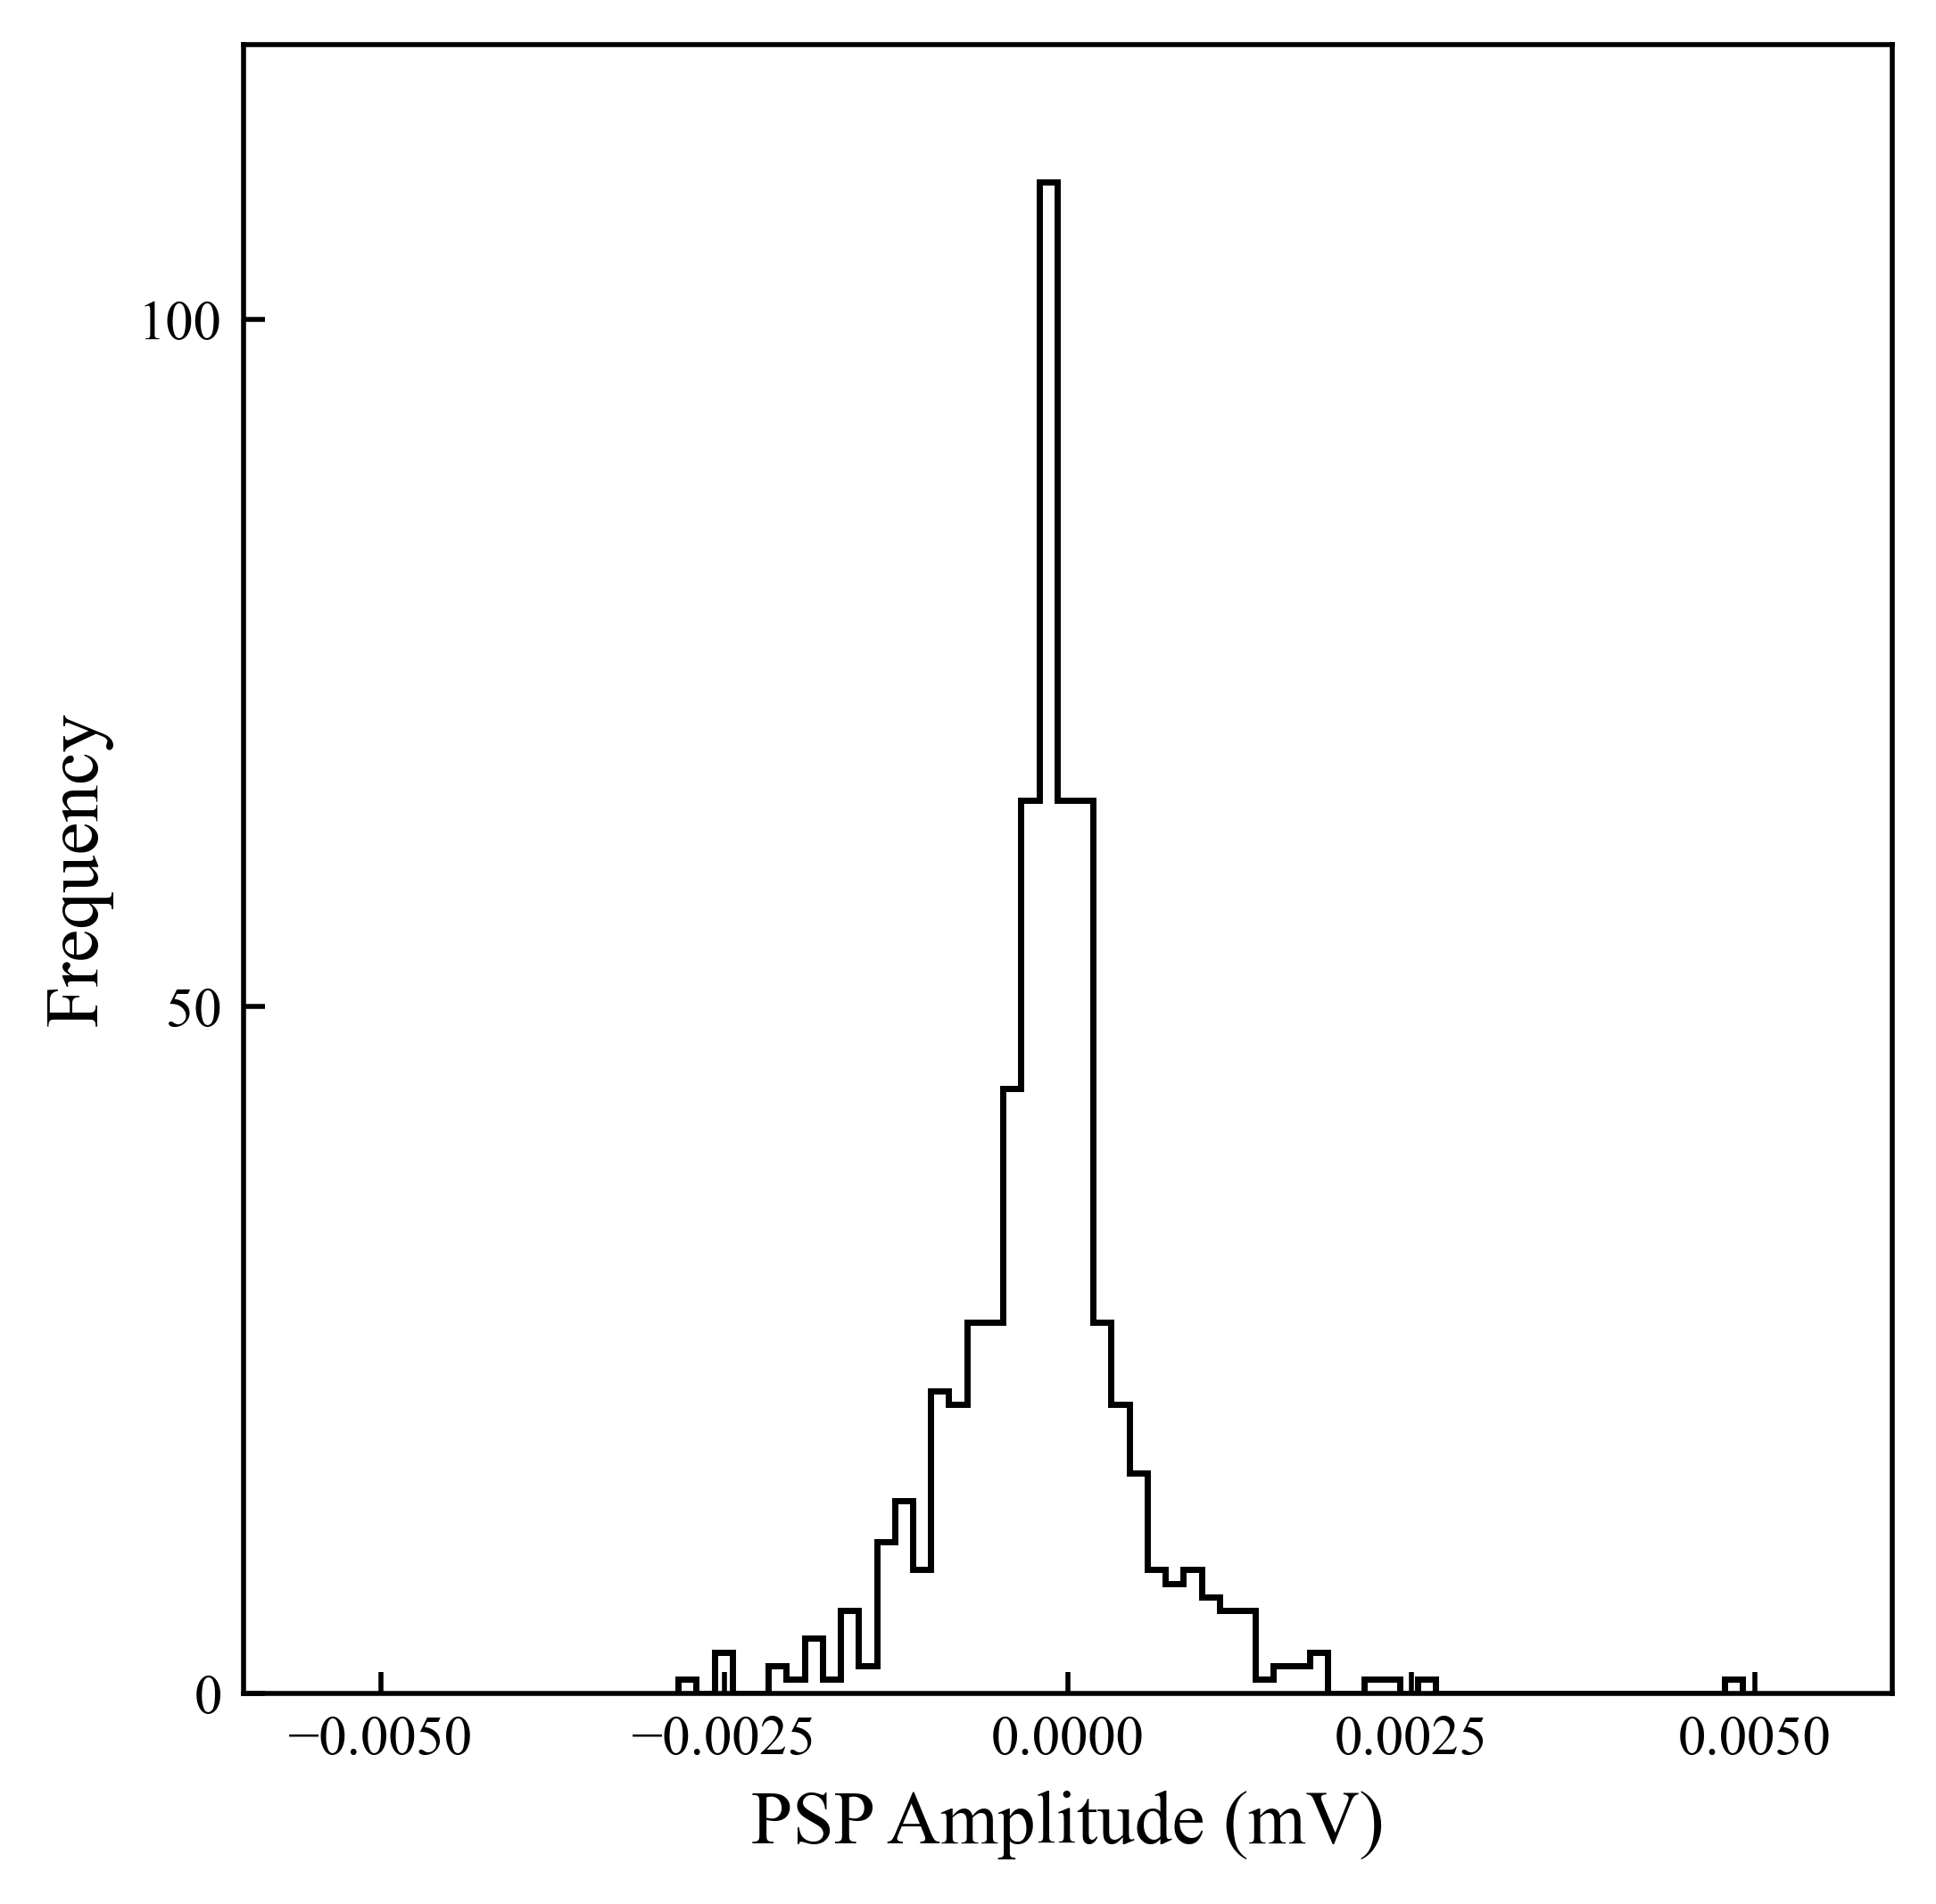

Saved figure to c:\Users\snrambo\Projects\NEVR3901\HeterogenousRNN\HeterogeneousRNNs\data_analysis\figures_analysis\july\histo_fi.svg


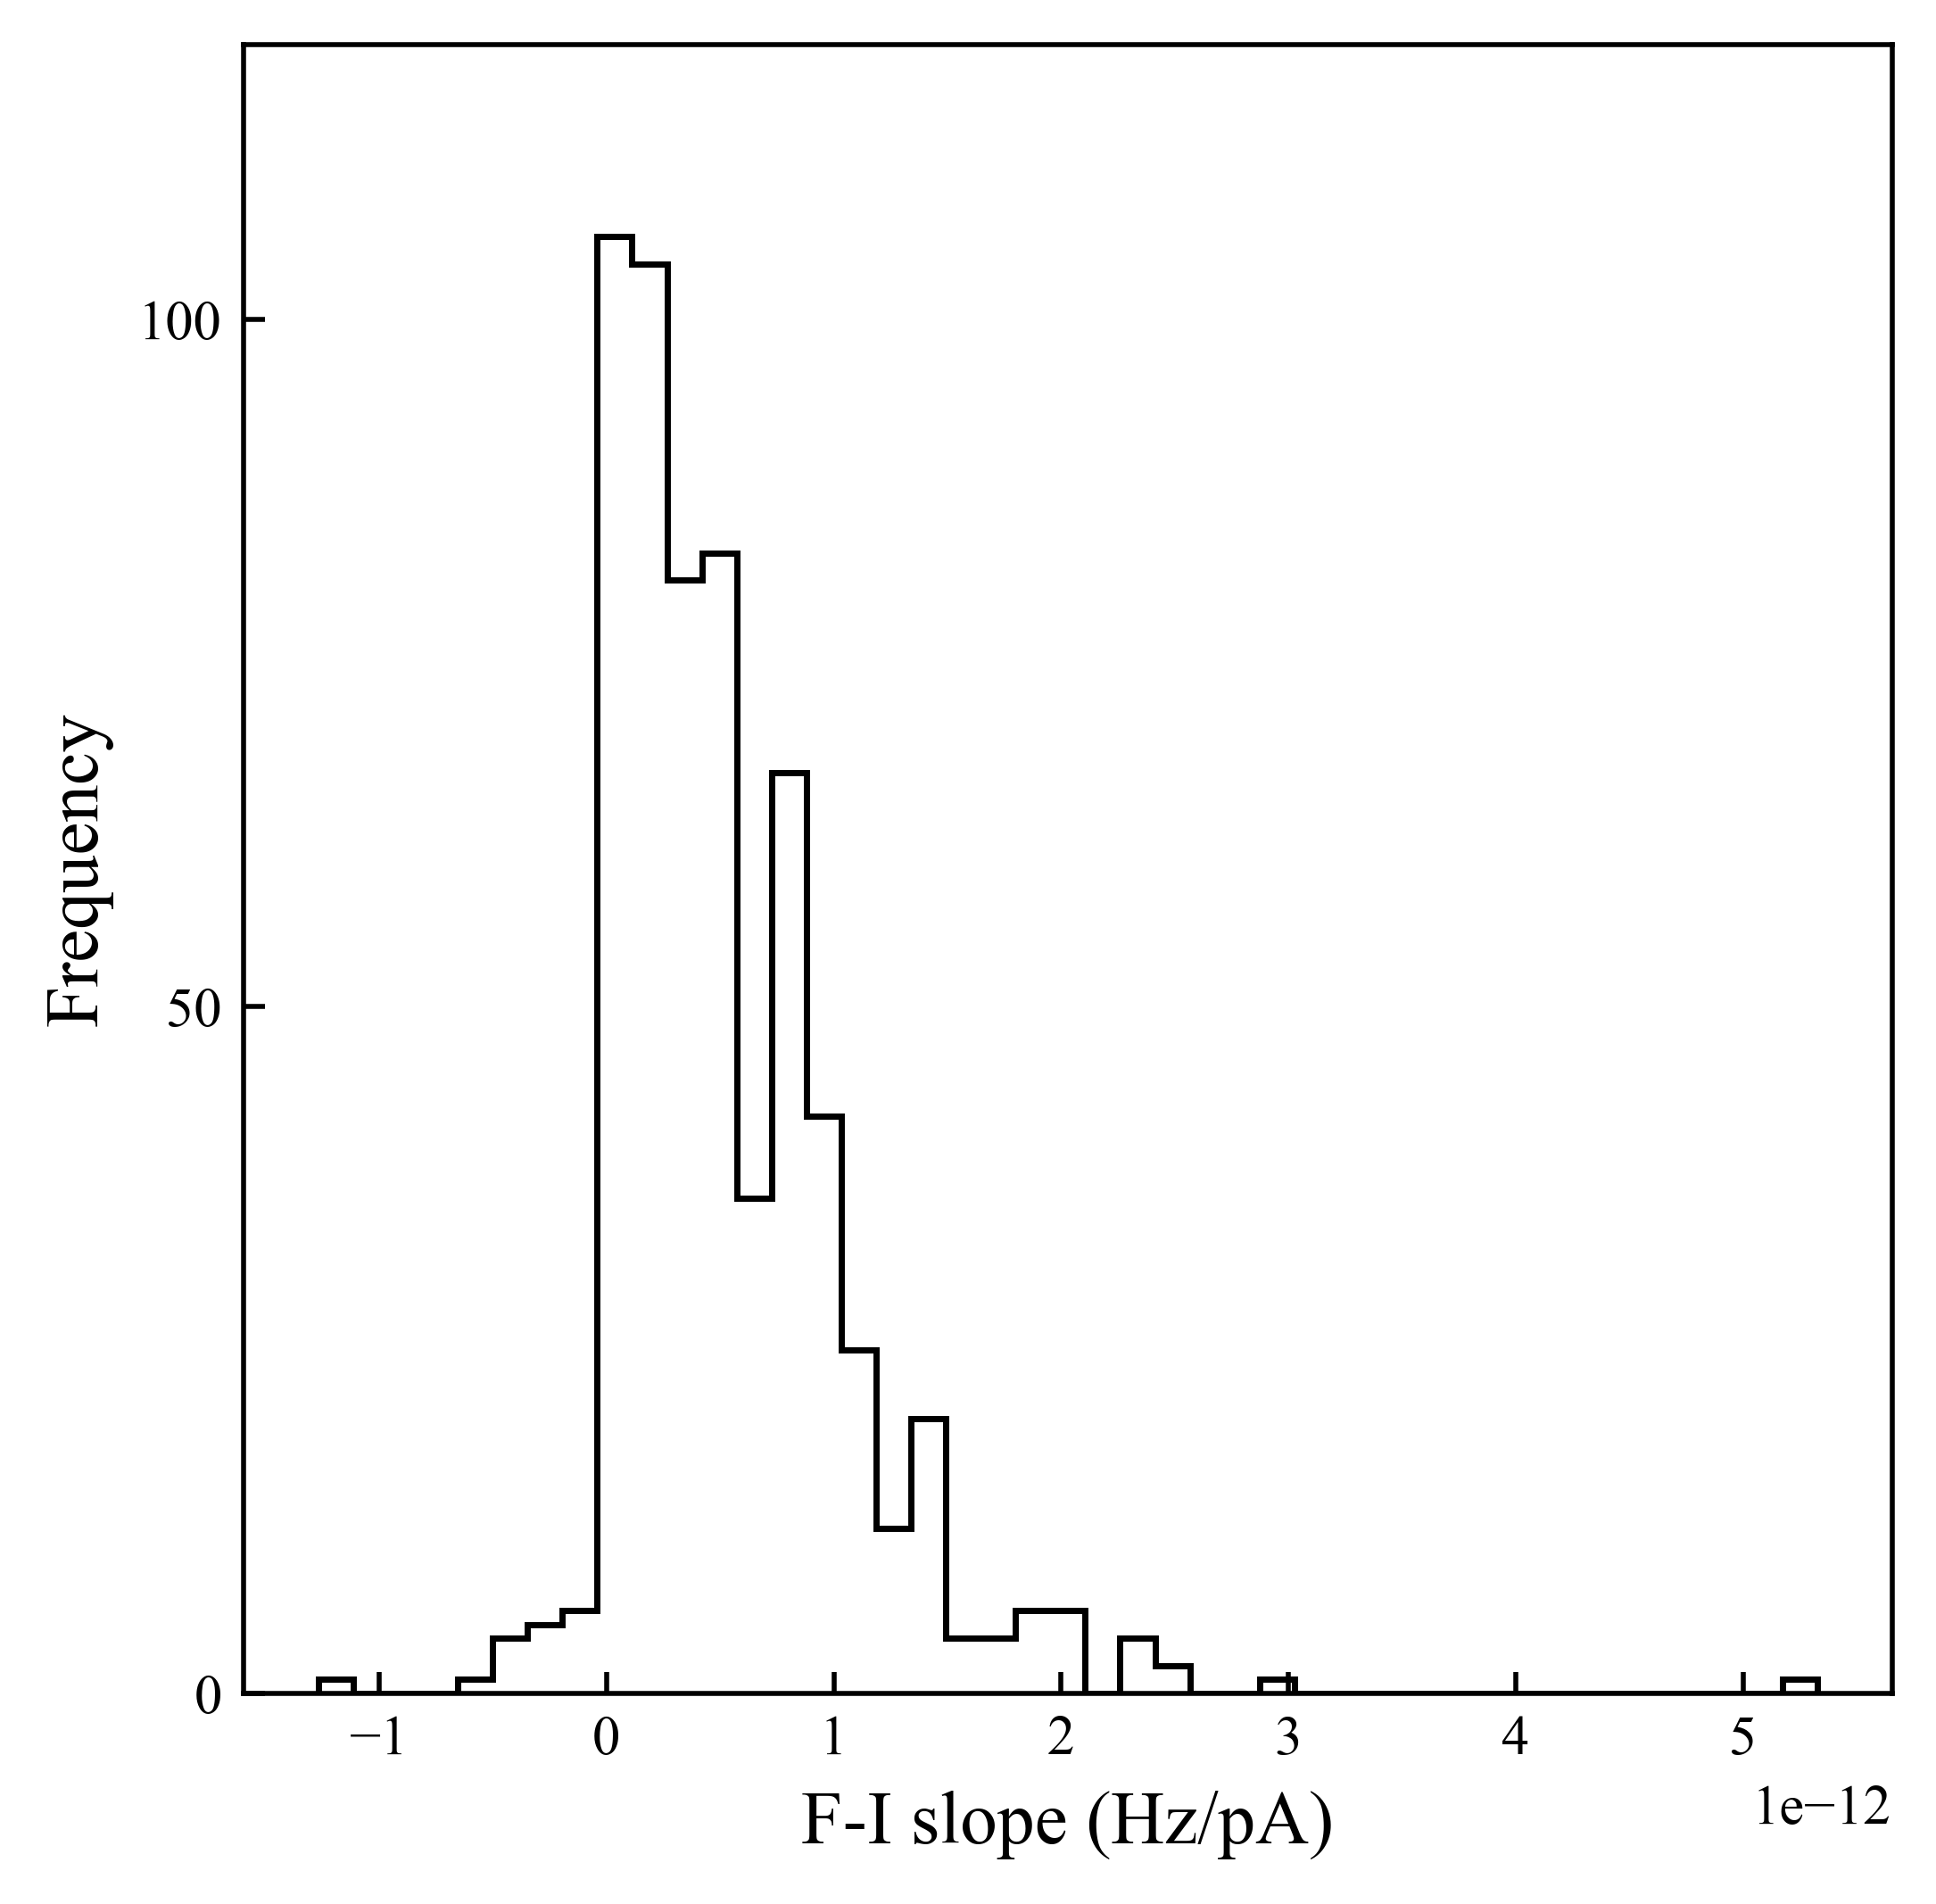

Pearson r = -0.207, p = 1.295e-05
Spearman rho = -0.208, p = 1.177e-05
Saved figure to c:\Users\snrambo\Projects\NEVR3901\HeterogenousRNN\HeterogeneousRNNs\data_analysis\figures_analysis\july\psp_fi_corr.svg


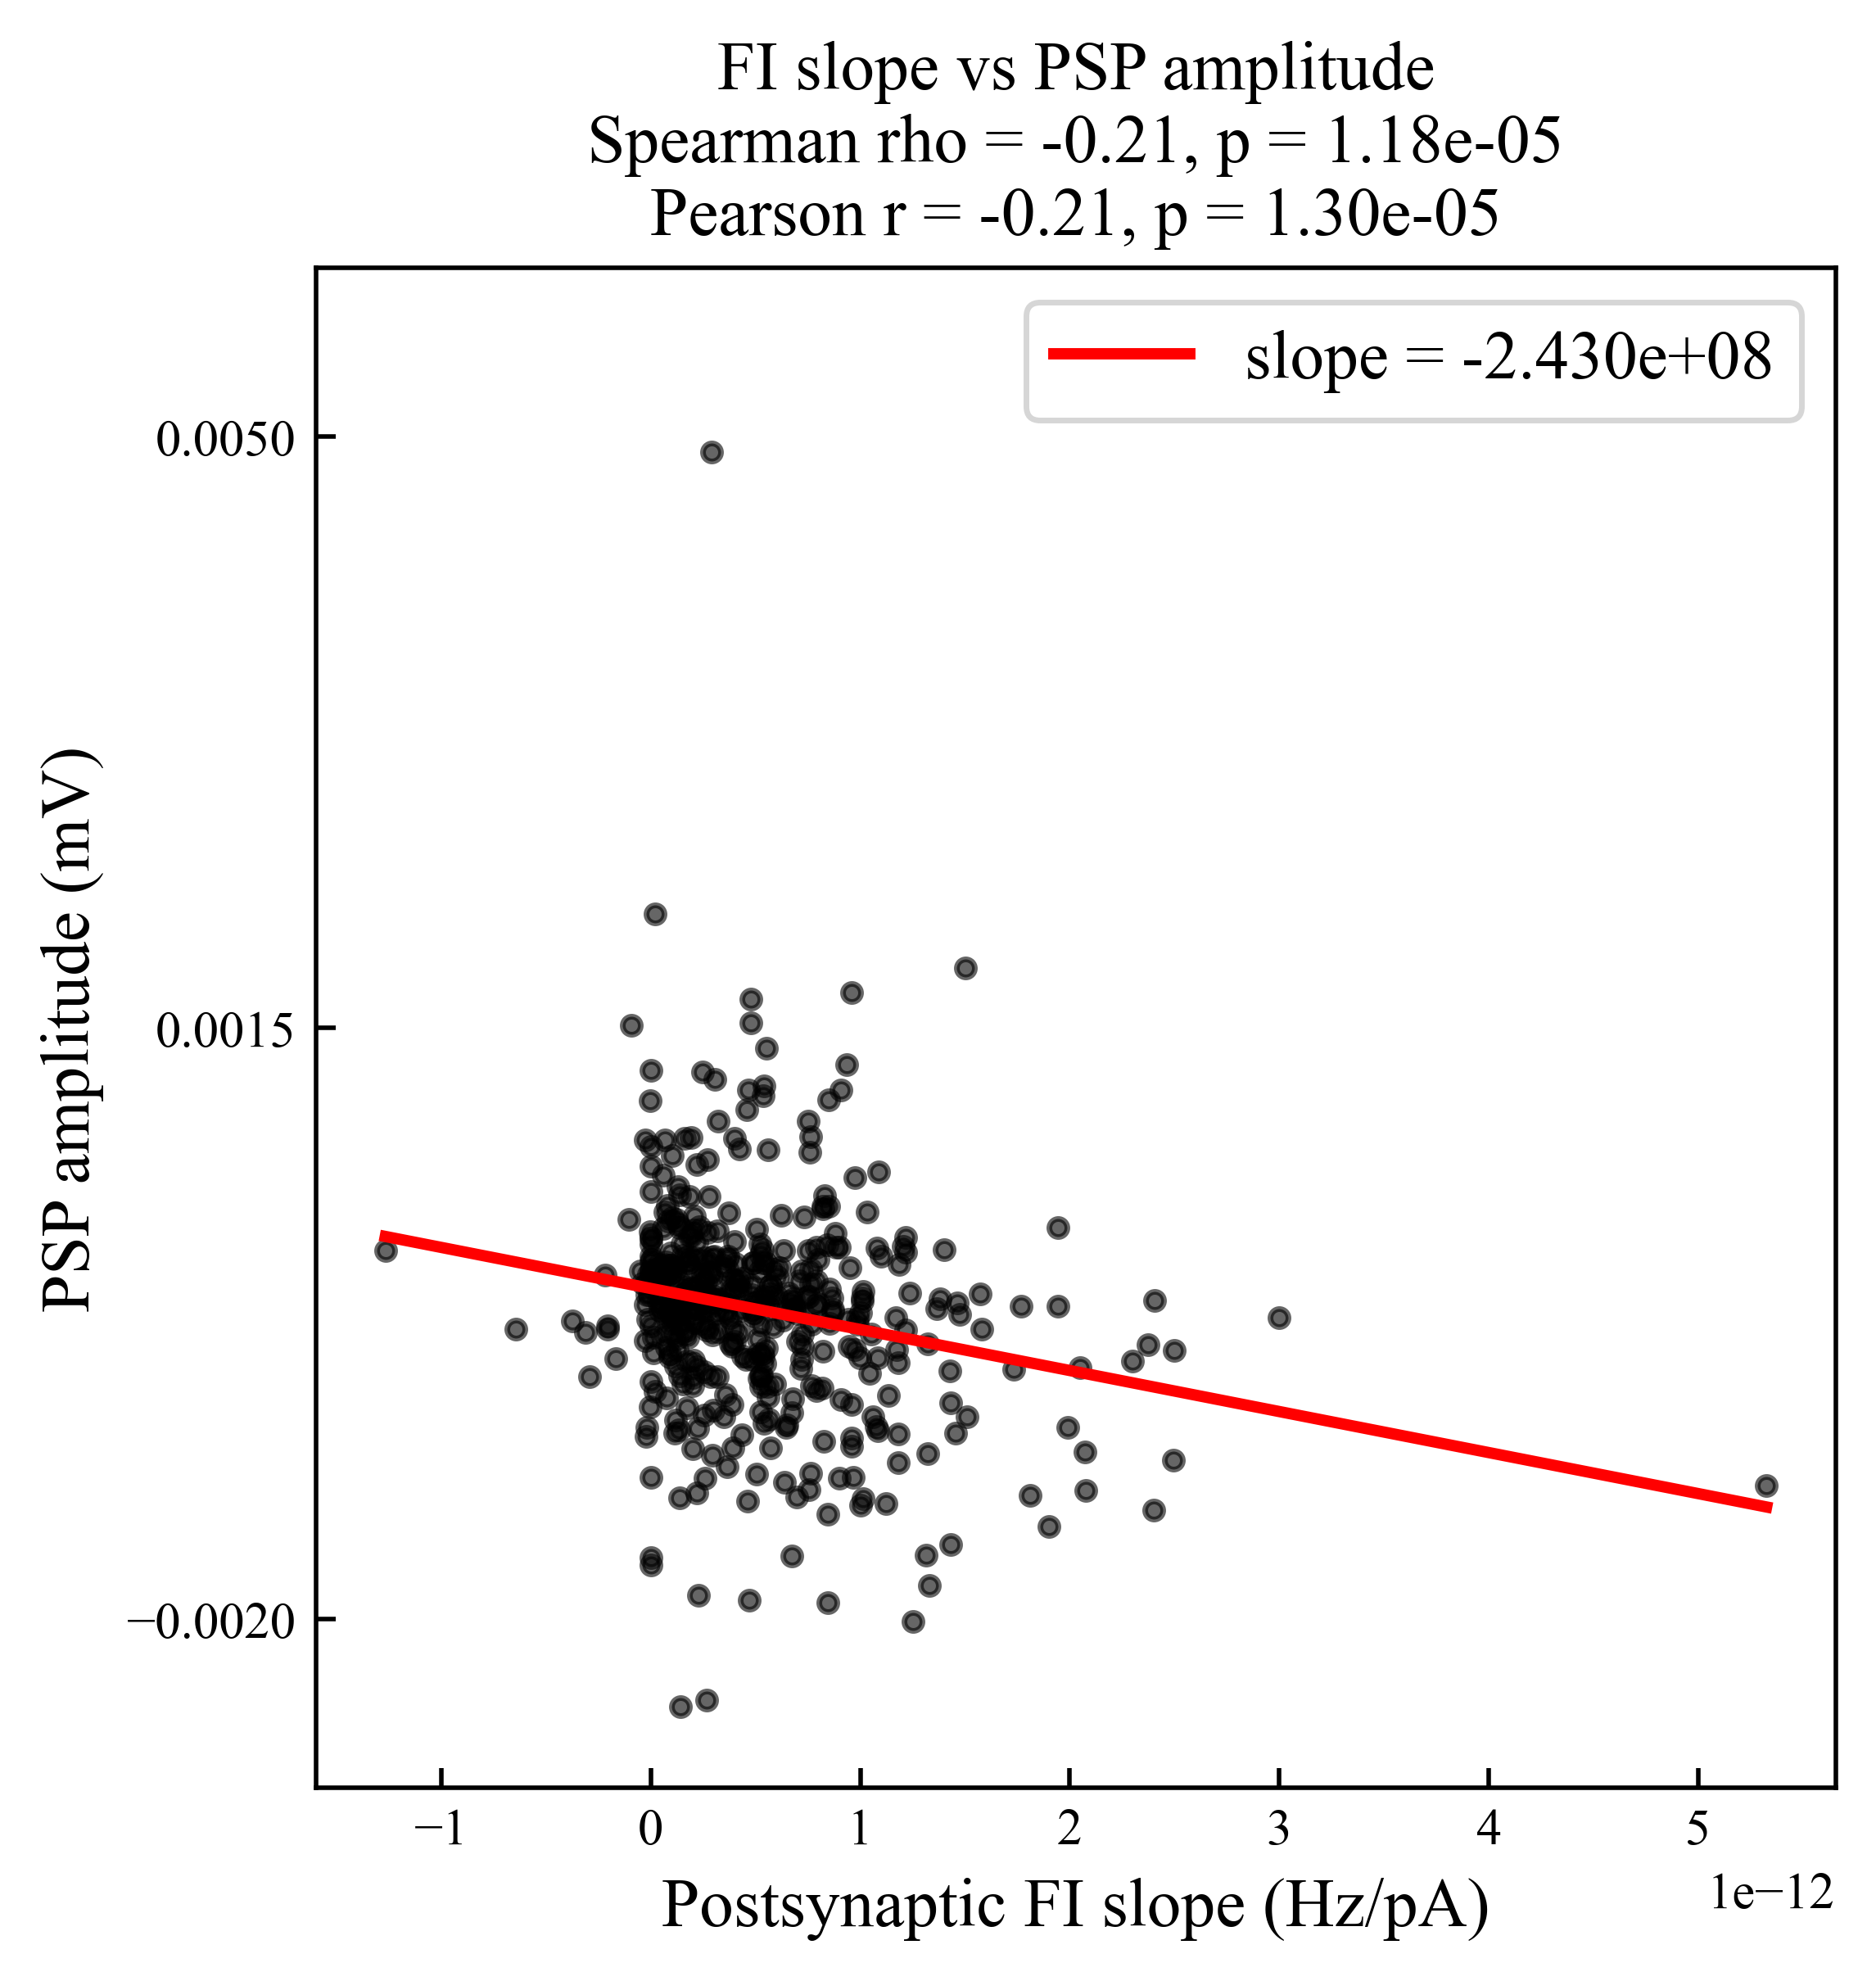

From here old code


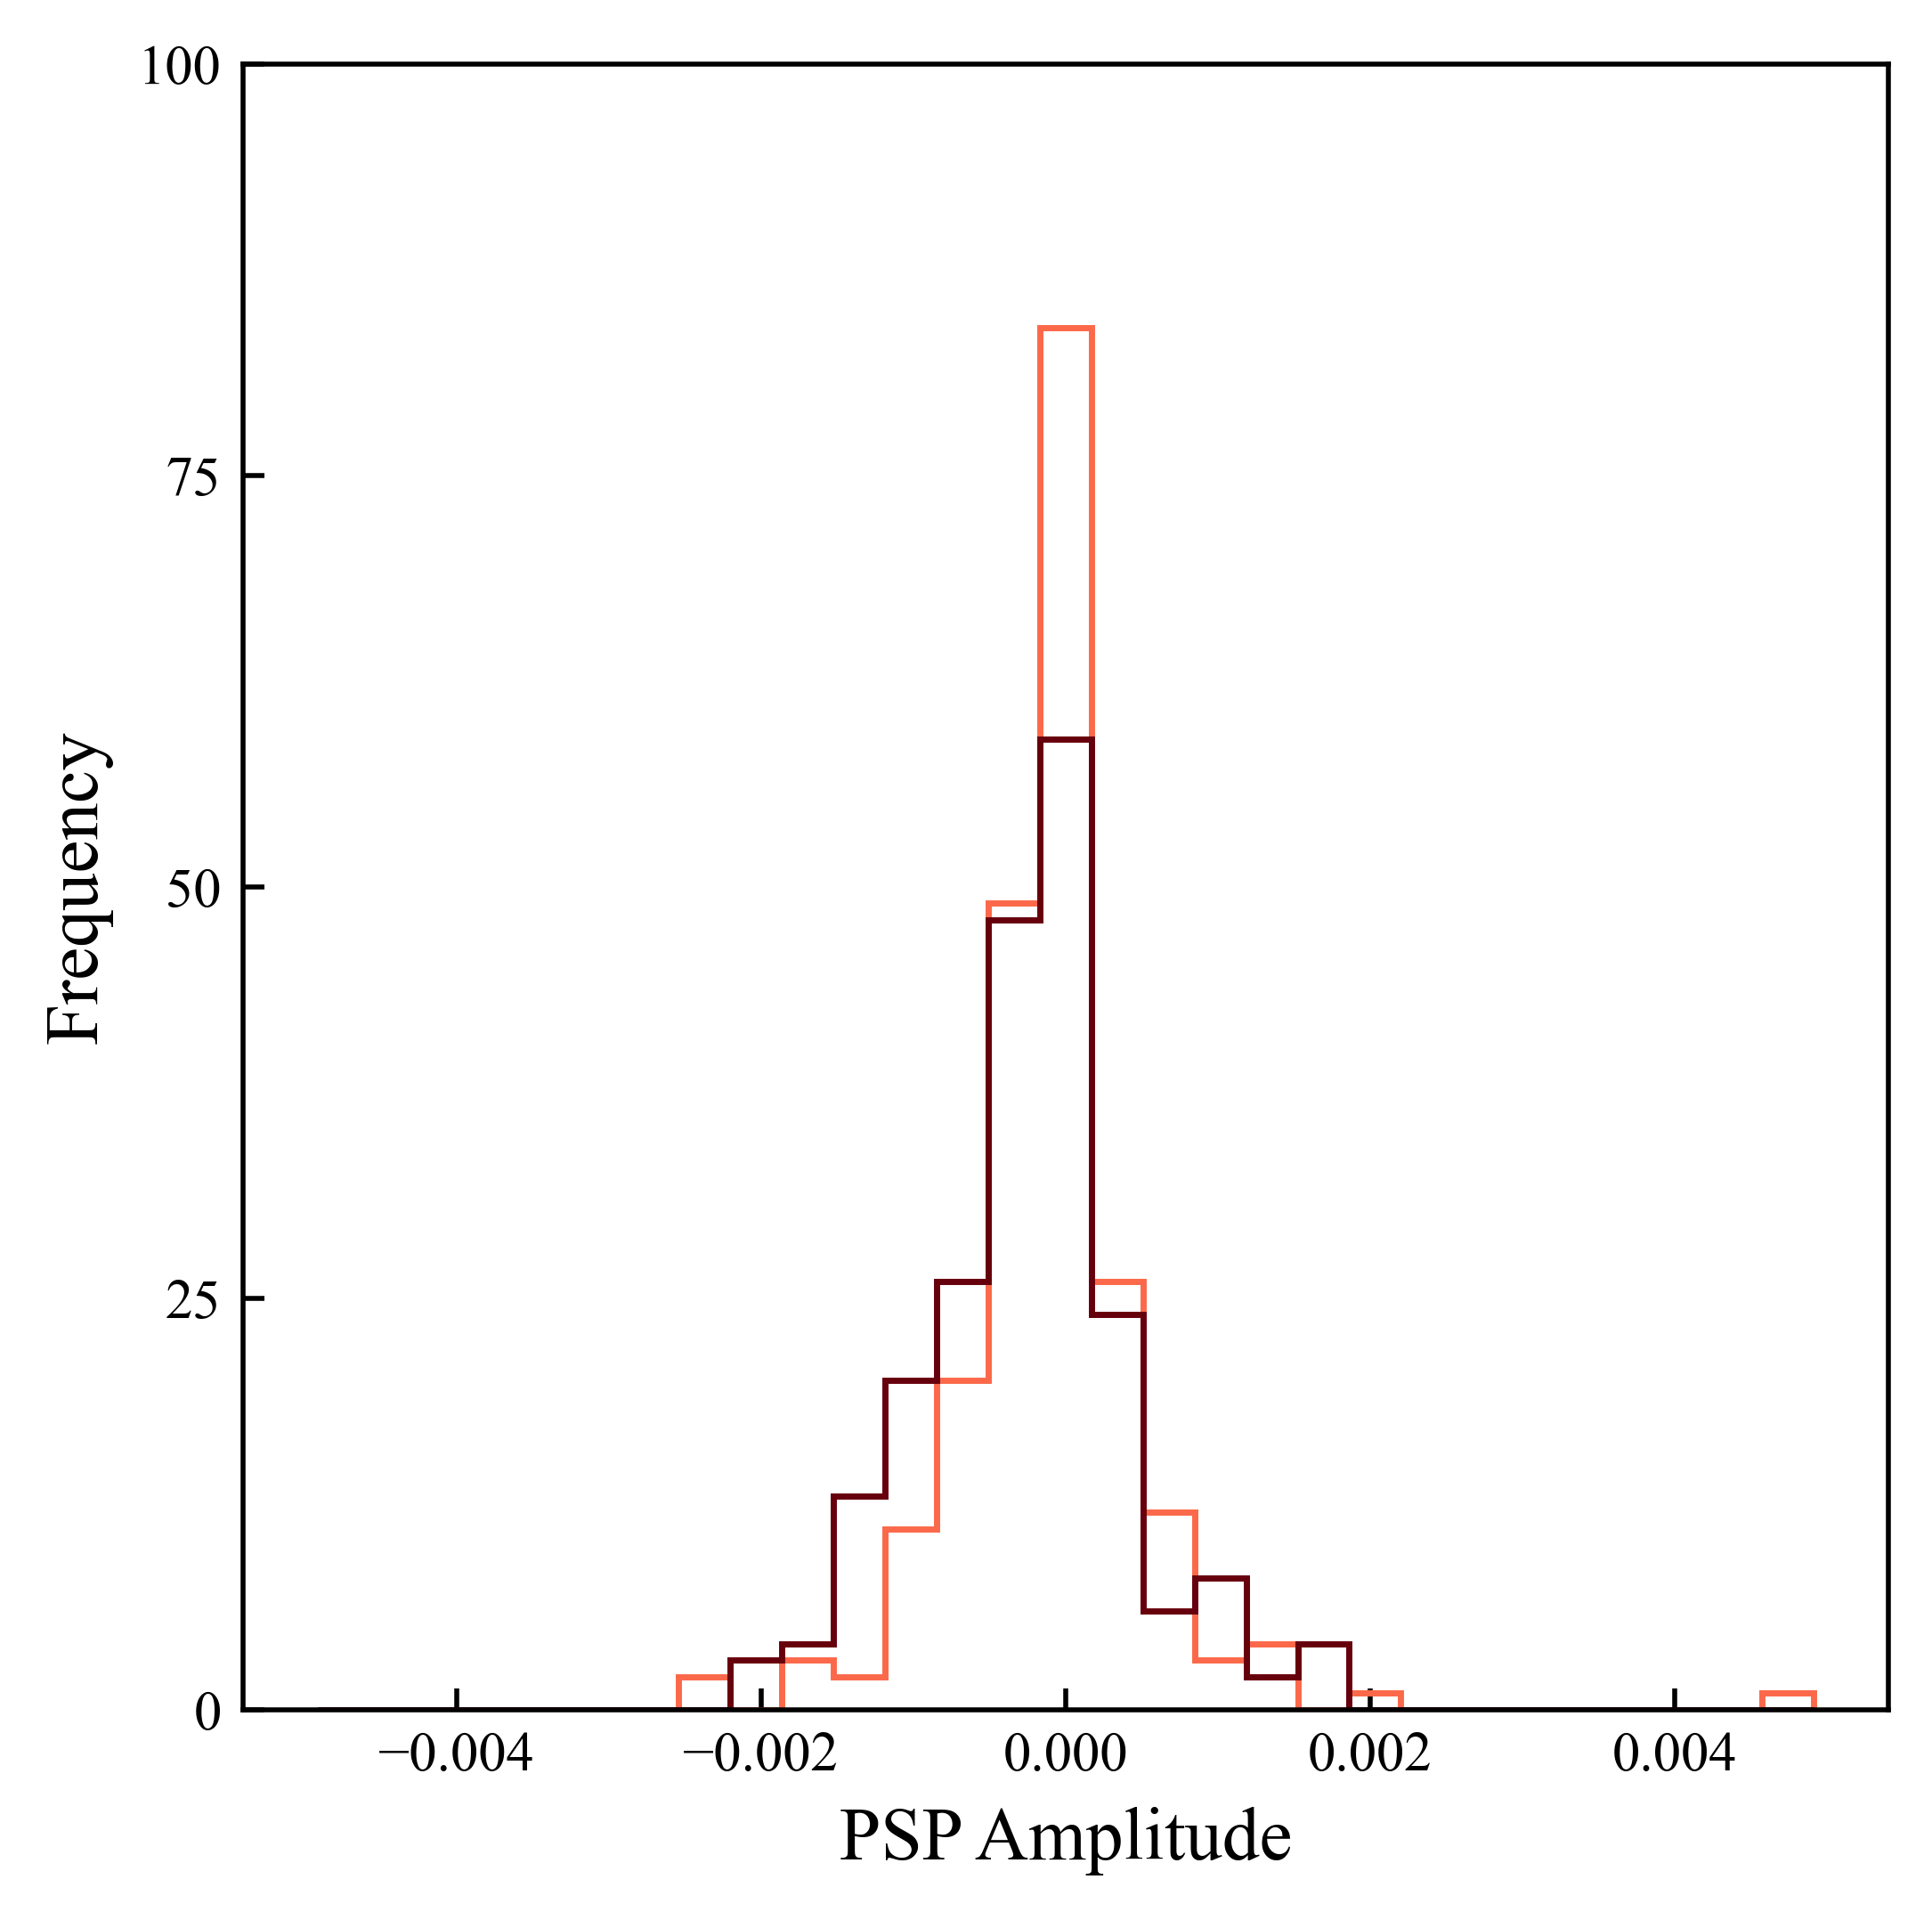

---- Mean and standard deviation for categories ----
['small', 'high']
[np.float64(-9.00103303768951e-05), np.float64(-0.0002538585284149066)]
[np.float64(0.0006634744845307342), np.float64(0.0006700535962011935)]


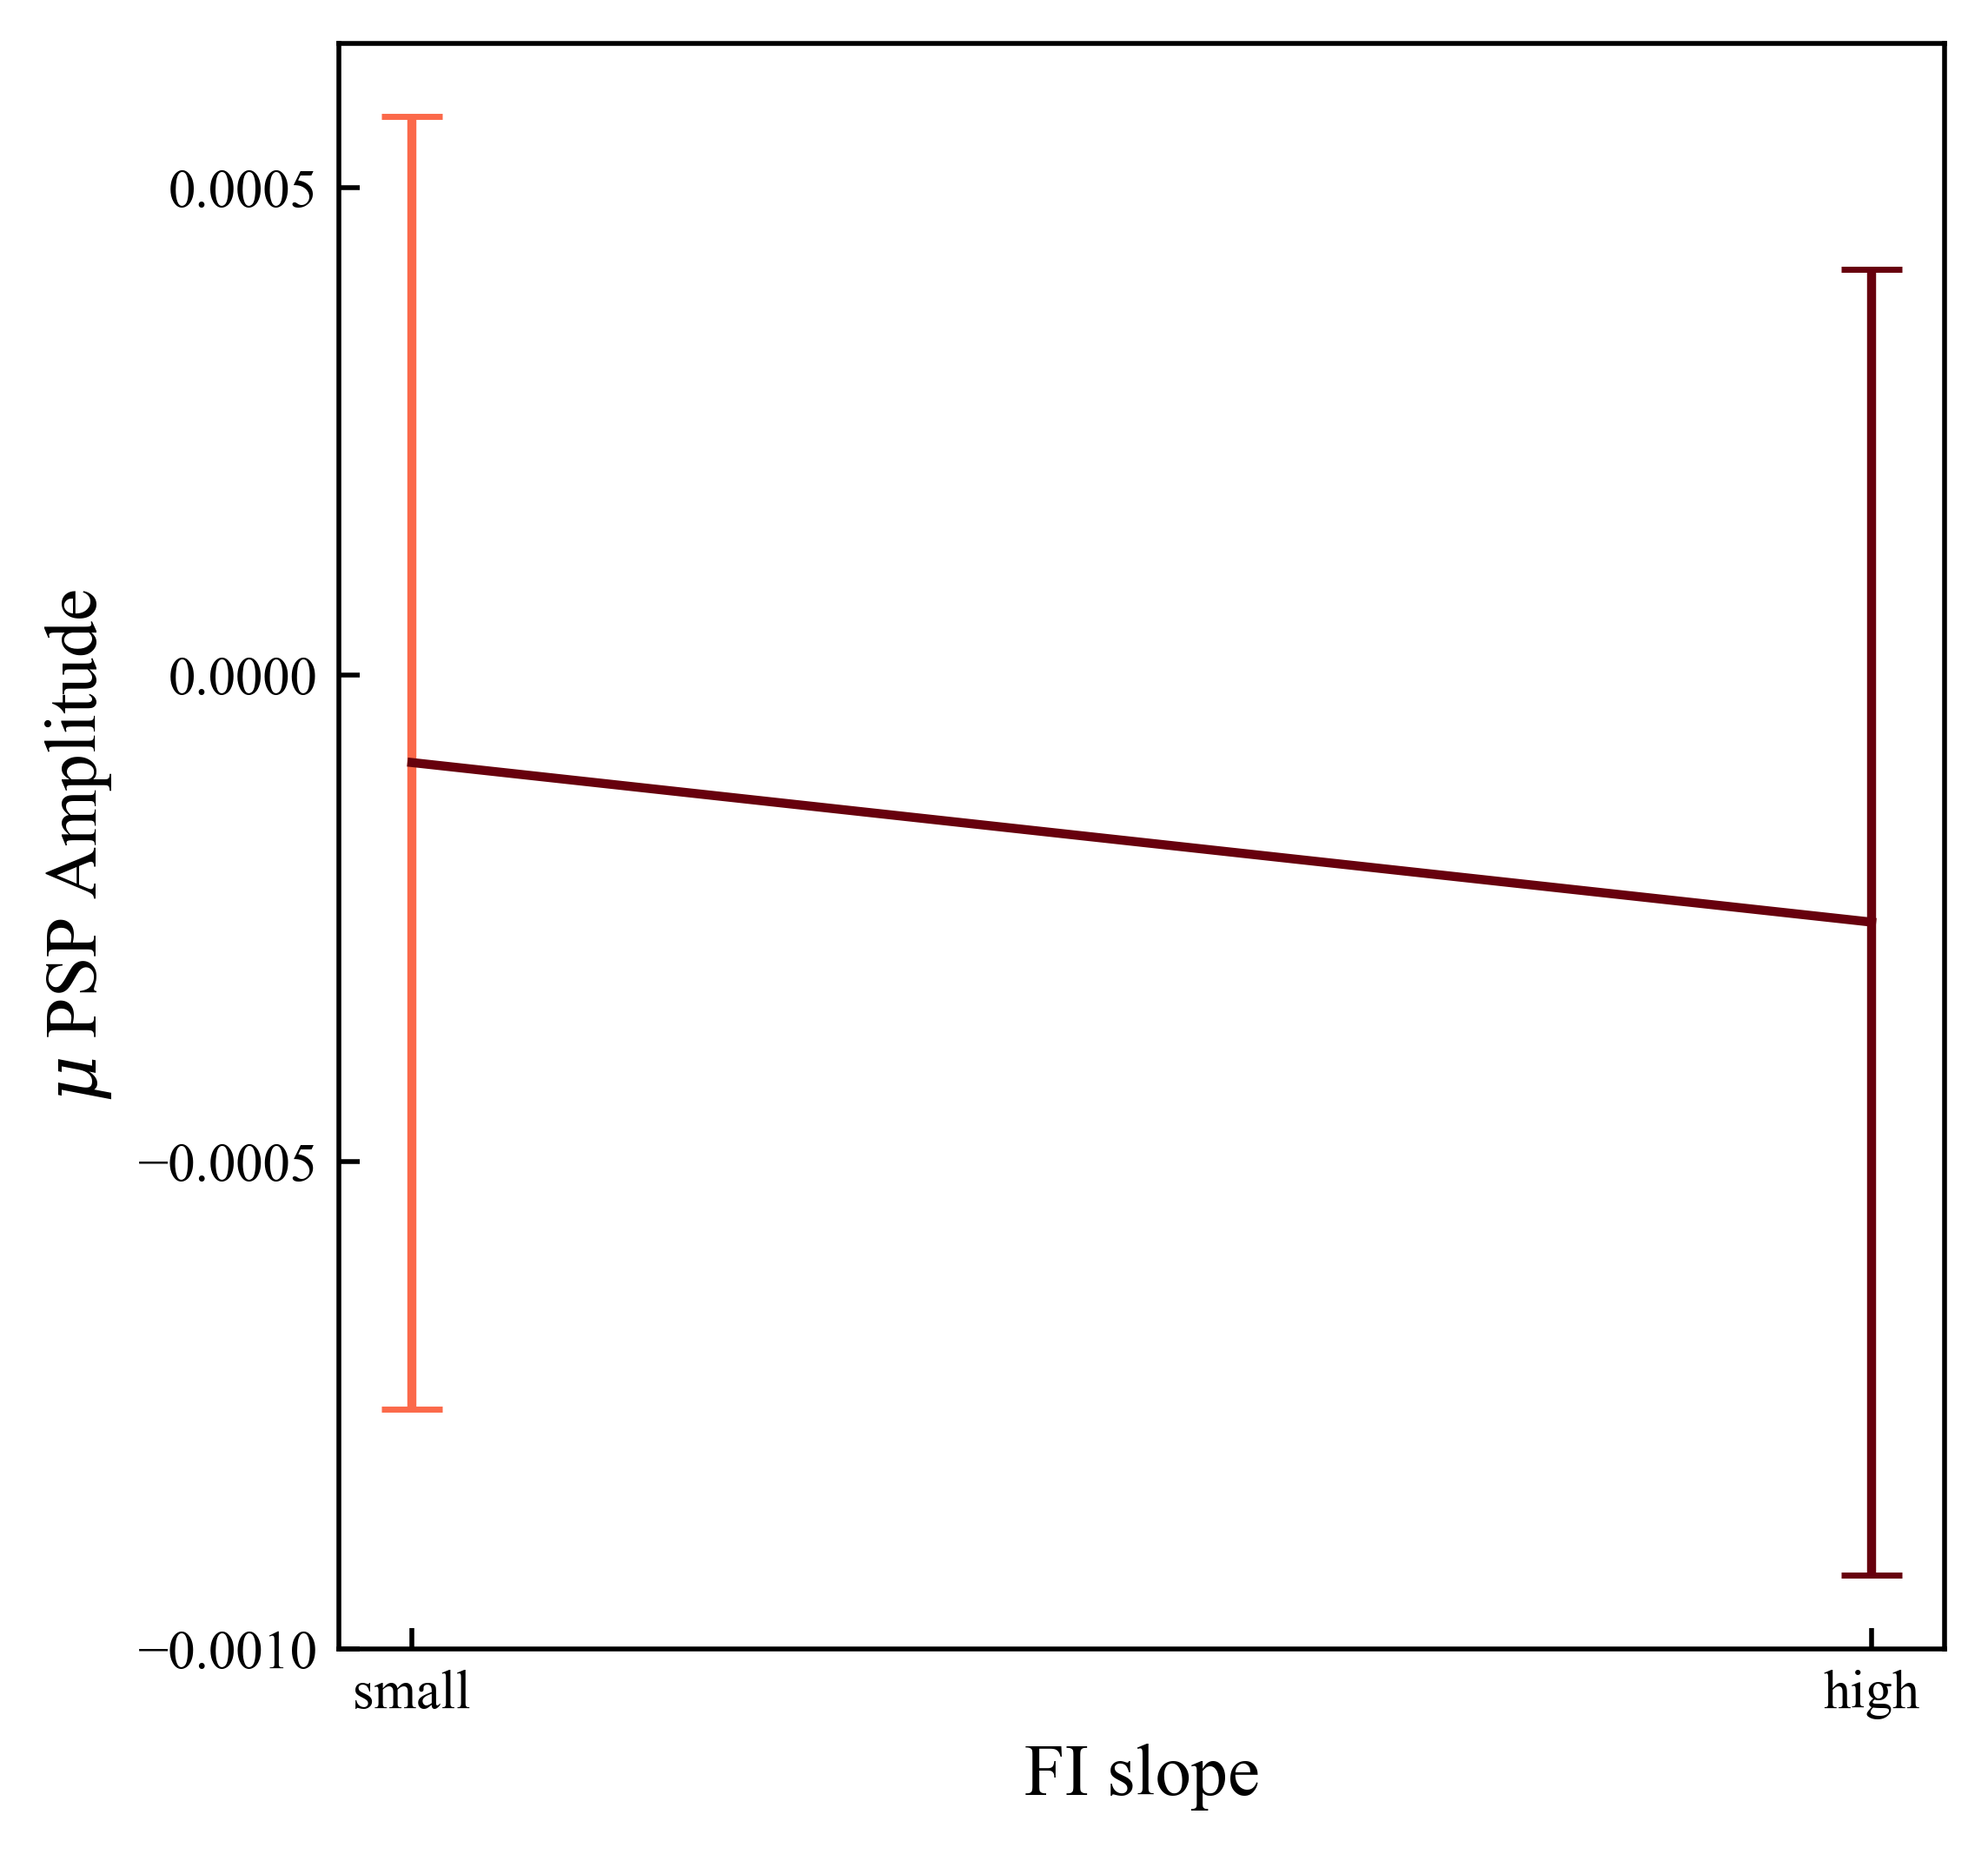

[np.float64(-9.00103303768951e-05), np.float64(-0.0002538585284149066)]
[np.float64(0.0006634744845307342), np.float64(0.0006700535962011935)]


In [22]:
# Import data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------

# File path handling

SCRIPT_DIR = Path.cwd()  # .ipynb
DATA_PATH = Path("preprocessed_data.csv")
FIGURES_DIR = SCRIPT_DIR / "figures_analysis" / "july"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)   # creates if needed


# Load matplotlib style (handles if in another folder)
from pathlib import Path
cwd = Path.cwd()
while not (cwd / "plos.mplstyle").exists():
    cwd = cwd.parent

style_path = Path(cwd / 'plos.mplstyle')
plt.style.use(style_path)


# ------------------------------------------------------------

# Dataframe

dfA = pd.read_csv("preprocessed_data.csv")  # Read the csv created from main query
df = dfA.dropna(subset=["psp_amplitude"])  # exclude those that contain NaN values in PSP amplitude



# ------------------------------------------------------------

# Functions


def make_color_map(values, cmap, vmin=0.50, vmax=1):
    '''
    Function that takes array of values and make a colormap for them
    '''

    colors = cmap(np.linspace(vmin, vmax, len(values)))

    return dict(zip(values, colors))



# ------------------------------------------------------------



# Distribution of PSP amplitude

fi_slopes = df["fi_slope_post"].tolist()
print(F"FI slopes: {fi_slopes}")

fig, ax = plt.subplots()

ax.hist(df["psp_amplitude"], 
        bins='auto', 
        histtype='step', 
        color='black',
        linewidth=1
        )
ax.set_xlabel("PSP Amplitude (mV)")
ax.set_ylabel("Frequency")
ax.set_xlim(-0.006, 0.006)
ax.set_xticks(np.arange(-0.005, 0.006, 0.0025))
# ax.set_yticks(np.arange(0, 125, 25))
ax.set_yticks(np.linspace(0, 100, 3))
ax.set_ylim(0, 120)
ax.set_box_aspect(1)

fig_path = FIGURES_DIR / f'histo_psp.svg'
fig.savefig(fig_path, dpi=500)
print(f"Saved figure to {fig_path}")

plt.show()


# ------------------------------------------------------------

# Distribution of F-I slopes

fig, ax = plt.subplots()

ax.hist(df["fi_slope_post"], 
        bins='auto', 
        histtype='step', 
        color='black',
        linewidth=1
        )
ax.set_xlabel("F-I slope (Hz/pA)")
ax.set_ylabel("Frequency")
ax.set_yticks(np.linspace(0, 100, 3))
ax.set_ylim(0, 120)
ax.set_box_aspect(1)

fig_path = FIGURES_DIR / f'histo_fi.svg'
fig.savefig(fig_path, dpi=500)
print(f"Saved figure to {fig_path}")

plt.show()

# ------------------------------------------------------------

# PSP Amplitude vs. F-I slope
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# To not overrepresent some data, for this we only include those postsynaptic neurons that appear once

# Count how many synapses each postsynaptic neuron appears in
synapse_counts = (
    df
    .groupby("post_cell_id")
    .size()
)

# Keep neurons that appear exactly once
single_synapse_neurons = synapse_counts[synapse_counts == 1].index

# Filter dataframe
df = df[
    df["post_cell_id"].isin(single_synapse_neurons)
].copy()


x = df["fi_slope_post"]
y = df["psp_amplitude"]

# Correlations
r, p_pearson = pearsonr(x, y)
rho, p_spearman = spearmanr(x, y)

print(f"Pearson r = {r:.3f}, p = {p_pearson:.3e}")
print(f"Spearman rho = {rho:.3f}, p = {p_spearman:.3e}")

# Linear regression for plotting
m, b = np.polyfit(x, y, 1)

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = m * x_fit + b

# Plot
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    x,
    y,
    color="black",
    s=10,
    alpha=0.6,
)

ax.set_yticks(np.linspace(-0.002, 0.005, 3))
ax.set_ylim(-0.003, 0.006)

ax.plot(
    x_fit,
    y_fit,
    color="red",
    linewidth=2,
    label=f"slope = {m:.3e}"
)

ax.set_xlabel("Postsynaptic FI slope (Hz/pA)")
ax.set_ylabel("PSP amplitude (mV)")

ax.set_title(
    f"FI slope vs PSP amplitude\n"
    f"Spearman rho = {rho:.2f}, p = {p_spearman:.2e}\n"
    f"Pearson r = {r:.2f}, p = {p_pearson:.2e}"
)

ax.set_box_aspect(1)
ax.legend()
plt.tight_layout()

fig_path = FIGURES_DIR / f'psp_fi_corr.svg'
fig.savefig(fig_path, dpi=500)
print(f"Saved figure to {fig_path}")
plt.show()

print(f"From here old code")

# ------------------------------------------------------------

# Binning with two groups

median_fi = df["fi_slope_post"].median()
bins = [-np.inf, median_fi, np.inf]

labels = [
    "small",
    "high",
]


df["category"] = pd.cut(
    df["fi_slope_post"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df.to_csv('preprocessed_data_categorized_smallhigh.csv', index=False)  # Save to reusable csv

df["category"].value_counts()





color_map_fi = make_color_map(labels, plt.cm.Reds)  # Color map for slopes


# Get shared bins for histograms
all_vals = df["psp_amplitude"].values
max_abs = np.max(np.abs(all_vals))
xmin, xmax = -max_abs, max_abs
bins = np.linspace(xmin, xmax, 30)

fig, ax = plt.subplots()

for l in labels:
    df_hist = df[df["category"]==l]
    ax.hist(df_hist["psp_amplitude"], 
            bins=bins, 
            histtype='step', 
            linewidth=1,
            color=color_map_fi[l], 
            label=l)


ax.set_xlabel("PSP Amplitude")
ax.set_ylabel("Frequency")
ax.set_yticks(np.arange(0, 125, 25))
ax.set_box_aspect(1)
plt.show()

# fig_path = FIGURES_DIR / f'psp_fi_category.svg'
# plt.savefig(fig_path, dpi=300)
# print(f"Saved figure to {fig_path}")


# Mean with errorbars 

meanvals = []
stdvals = []
semvals = []

labels = [
    "small",
    "high",
]

for l in labels:
    df_filtered = df[(df[f"category"]==l) & (df["has_synapse"]==1)]  # this category across experiments

    # Mean of PSP Amplitude across experiments for current category
    mean_psp = df_filtered["psp_amplitude"].mean()  
    meanvals.append(mean_psp)

    # Standard deviation of PSP amplitude across experiments
    std_psp = df_filtered["psp_amplitude"].std()  # Is sample std by default
    sem_psp = df_filtered["psp_amplitude"].sem()
    stdvals.append(std_psp)
    semvals.append(sem_psp)


print(f"---- Mean and standard deviation for categories ----\n{labels}\n{meanvals}\n{stdvals}")


# ------------- Mean with errorbars ---------


fig, ax = plt.subplots(
                    nrows=1, 
                    ncols=1, 
    )
for l, y, yerr in zip(labels, meanvals, stdvals):
    ax.errorbar(l, y, yerr, capsize=5, color=color_map_fi[l])
    
ax.plot(labels, meanvals, color=color_map_fi[l])
ax.set_ylabel(f"$\mu$ PSP Amplitude")
ax.set_xlabel(f"FI slope")
ax.set_box_aspect(1)
ax.set_yticks(np.arange(-0.001, 0.0006, 0.0005))
plt.show()

# fig_path = FIGURES_DIR / f'mean_fi.svg'
# plt.savefig(fig_path, dpi=300)
# print(f"Saved figure to {fig_path}")


print(meanvals)
print(stdvals)



# Wilcoxon signed-rank test

Non-parametric rank test for statistical testing of paired differences.

For each experiment, assign a mean value for PSP Amplitude within the small vs high category. Therefore we keep only experiments that have both.

The null hypothesis is "within experiments, small and high categories do not systematically differ in PSP amplitude". If two sided, the alternative hypothesis is that the difference is not zero (not specifically smaller or larger).

In [30]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import itertools



df = pd.read_csv("preprocessed_data_categorized_smallhigh.csv") # the dataframe that include categories
df = df[df['has_synapse'] == 1] # keep only synapses that really exist



# mean PSP amplitude for each (experiment, category) pair
# groups by experiment and category, take mean psp amplitude inside each group
# turn the series back into a dataframe
exp_means = (
    df
    .groupby(['experiment_id', 'category'])['psp_amplitude']
    .mean()                                   # can also use .median()
    .reset_index(name='mean_psp')
)



# pivot to a wide table: rows = experiments, cols = categories
# each cell value is the mean PSP for that experiment*category
wide = exp_means.pivot(index='experiment_id',
                       columns='category',
                       values='mean_psp')
print(wide.head())



def paired_wilcoxon(wide_df, cat_a, cat_b, tail='two-sided', exact=True):
    """
    Wilcoxon signed rank test on the paired per experiment means of two categories.

    Parameters:

    wide_df : pd.dataFrame
        the table to be examined
    cat_a, cat_b : str
        two categories to compare (ex: small, medium)
    tail : {'two-sided', 'greater', 'less'}
        Direction of the alternative hypothesis
    exact : bool
        If true, ask scipy for an exact p-value. Possible only when num of nonzero pairs <= 30
    
    Returns
    dict with test statistic, raw p-value, number of paired observations, and rank-biserial correlation (effect size)

    
    """
    # keep only experiments that have BOTH categories
    pair = wide_df[[cat_a, cat_b]].dropna()
    n = len(pair)

    if n == 0:
        return {'cat1': cat_a, 'cat2': cat_b,
                'statistic': np.nan, 'pvalue': np.nan,
                'n': 0, 'effect_size': np.nan}

    # differences (a - b)
    diff = pair[cat_a] - pair[cat_b]

    # Wilcoxon signed‑rank
    mode = 'exact' if exact else 'approx'
    W, p = stats.wilcoxon(diff,
                          zero_method='wilcox',
                          alternative=tail,
                          mode=mode)

    # rank‑biserial correlation (effect size)
    n_nonzero = np.sum(diff != 0)
    r_rb = 1 - (2 * W) / (n_nonzero * (n_nonzero + 1))

    return {'cat1': cat_a, 'cat2': cat_b,
            'statistic': W,
            'pvalue': p,
            'n': n,
            'effect_size': r_rb}

categories = wide.columns.tolist()       # fi slope categories, ex: ['small','medium','high']
pairwise = []

for c1, c2 in itertools.combinations(categories, 2):
    pairwise.append(paired_wilcoxon(wide, c1, c2,
                                    tail='two-sided', exact=True))

pairwise_df = pd.DataFrame(pairwise)
print(pairwise_df[['cat1','cat2','n','statistic','pvalue','effect_size']])

pairwise_df


# Bonferroni correction not needed for two pairs

# print("Bonferroni correction")
# m = len(pairwise_df)                     # = 3
# pairwise_df['p_corr'] = np.minimum(pairwise_df['pvalue'] * m, 1.0)
# # print(pairwise_df[['cat1','cat2','pvalue','p_corr','effect_size']])

# pairwise_df



category           high     small
experiment_id                    
600            0.000445 -0.000204
610                 NaN  0.000030
614                 NaN -0.000168
699                 NaN  0.000038
700           -0.000126       NaN
   cat1   cat2   n  statistic    pvalue  effect_size
0  high  small  38      191.0  0.008338      0.74224


,cat1,cat2,statistic,pvalue,n,effect_size
0,high,small,191.0,0.008338,38,0.74224
